In [56]:
# load dot env
from dotenv import load_dotenv
import os
load_dotenv()

False

In [57]:
# import all libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels
import yfinance as yf
import os
from util import get_data

In [58]:
CURRENCY = '^DJI'
MODEL_TYPE = "Naive"
COIN_ORDERS = 0.005
DAYS = 30

btc = get_data(CURRENCY)
btc.head()

c:\Users\akash\Documents\Coding Projects\CoolCryptoCode\util.py:15: FutureWarning:

In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`



,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2024-10-07 09:30:00-04:00,42289.511719,42293.640625,42133.890625,42187.300781,58269231,0.0,0.0
2024-10-07 11:00:00-04:00,42188.019531,42250.511719,42060.988281,42105.261719,38407125,0.0,0.0
2024-10-07 12:30:00-04:00,42105.449219,42142.140625,42025.691406,42054.960938,29177393,0.0,0.0
2024-10-07 14:00:00-04:00,42055.160156,42055.160156,41831.738281,41956.941406,47522009,0.0,0.0
2024-10-07 15:30:00-04:00,41956.570312,42012.109375,41902.621094,41952.679688,37638074,0.0,0.0


In [59]:
dir(btc.index)

# get last 30 days
btc.index[-1] - pd.DateOffset(days=1)

Timestamp('2024-12-04 15:30:00-0500', tz='UTC-05:00')

' plt.xlim(btc.index[-1] - pd.DateOffset(days=DAYS), btc.index[-1]) '

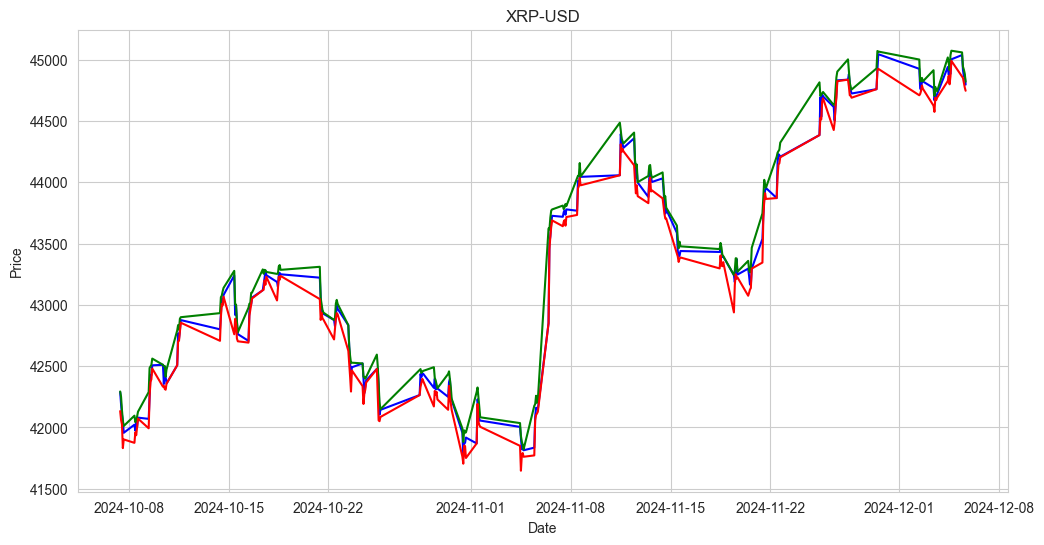

In [60]:
# plot open, high, and low
sns.set_style('whitegrid')

plt.figure(figsize=(12, 6))

plt.plot(btc['Open'], label='Open', color='blue')
plt.plot(btc['High'], label='High', color='green')
plt.plot(btc['Low'], label='Low', color='red')

plt.title('XRP-USD')
plt.xlabel('Date')
plt.ylabel('Price')

DAYS = 3

""" plt.xlim(btc.index[-1] - pd.DateOffset(days=DAYS), btc.index[-1]) """

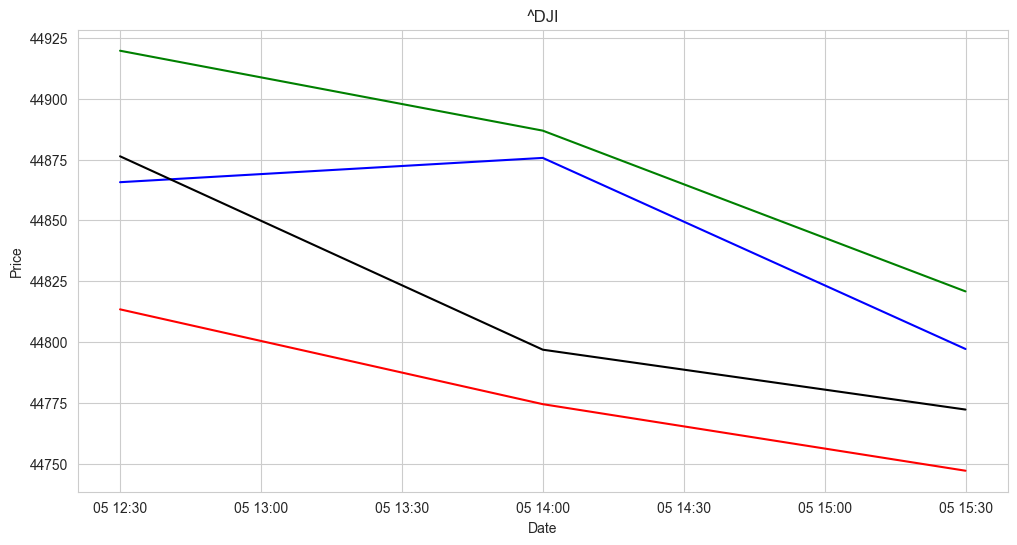

In [61]:
# make a candlestick stock plot with open, high, low, close
plt.figure(figsize=(12, 6))

plt.plot(btc.index[-DAYS:], btc['Open'][-DAYS:], label='Open', color='blue')
plt.plot(btc.index[-DAYS:], btc['High'][-DAYS:], label='High', color='green')
plt.plot(btc.index[-DAYS:], btc['Low'][-DAYS:], label='Low', color='red')
plt.plot(btc.index[-DAYS:], btc['Close'][-DAYS:], label='Close', color='black')

plt.title(CURRENCY)
plt.xlabel('Date')
plt.ylabel('Price')

plt.show()

In [62]:
import random

# Initialize Positions DataFrame
positions = pd.DataFrame(columns=["Date Bought", "Price Bought", "Price Sold", "Value Sold", "Time Sold", "Time Held", "Gross Profit"])

cash_balance = 10000  # Starting cash
crypto_balance = 0
positions = pd.DataFrame(columns=[
    "Date Bought", "Price Bought", "Price Sold", "Value Sold", 
    "Gross Profit", "Time Sold", "Time Held", "Type"
])
portfolio_value = []
profits_over_time = []
cash_over_time = []
crypto_over_time = []
time = []

def reset():
    global cash_balance, crypto_balance, positions, portfolio_value, profits_over_time, cash_over_time, crypto_over_time, time
    cash_balance = 10000  # Starting cash
    crypto_balance = 0
    positions = pd.DataFrame(columns=[
        "Date Bought", "Price Bought", "Price Sold", "Value Sold", 
        "Gross Profit", "Time Sold", "Time Held", "Coins", "Type"
    ])
    portfolio_value = []
    profits_over_time = []
    cash_over_time = []
    crypto_over_time = []
    time = []

In [87]:
def execute_trades(data, stop_loss_pct=0.05, limit_pct=0.1, coin_orders=10):
    """
    Executes trades on the data, supporting buying/selling multiple coins at once.

    Parameters:
    - data: DataFrame of price data.
    - stop_loss_pct: Stop loss percentage for closing positions.
    - limit_pct: Limit percentage for taking profits.
    - coin_orders: Number of coins to buy or sell in a single transaction.
    """
    global cash_balance, crypto_balance, positions

    for i in range(0, len(data) - 1, 1):  # Every 90 minutes
        row = data.iloc[i]
        price = row['Open']
        date = row.name
        # action = random.choice(["buy", "nothing", "short"])  # Random action
        probs = [0.4, 0.2, 0.4]  # Probabilities for buy, nothing, short
        action = np.random.choice(["buy", "nothing", "short"], p=probs)

        # Check for stop/limit order criteria
        for idx, position in positions[positions["Price Sold"].isna()].iterrows():
            if position["Type"] == "buy":
                stop_price = position["Price Bought"] * (1 - stop_loss_pct)
                limit_price = position["Price Bought"] * (1 + limit_pct)
                if price <= stop_price or price >= limit_price:
                    # Sell to close buy position
                    coins_to_sell = min(coin_orders, crypto_balance)
                    crypto_balance -= coins_to_sell
                    cash_balance += coins_to_sell * price
                    gross_profit = coins_to_sell * (price - position["Price Bought"])
                    positions.loc[idx, "Price Sold"] = price
                    positions.loc[idx, "Value Sold"] = price * coins_to_sell
                    positions.loc[idx, "Gross Profit"] = gross_profit
                    positions.loc[idx, "Time Sold"] = date
                    positions.loc[idx, "Coins"] = coin_orders
                    positions.loc[idx, "Time Held"] = date - position["Date Bought"]

            elif position["Type"] == "short":
                stop_price = position["Price Bought"] * (1 + stop_loss_pct)
                limit_price = position["Price Bought"] * (1 - limit_pct)
                if price >= stop_price or price <= limit_price:
                    # Buy to cover short position
                    coins_to_cover = coin_orders  # All short positions are for `coin_orders`
                    cash_balance -= coins_to_cover * price
                    gross_profit = coins_to_cover * (position["Price Bought"] - price)
                    positions.loc[idx, "Price Sold"] = price
                    positions.loc[idx, "Value Sold"] = price * coins_to_cover
                    positions.loc[idx, "Gross Profit"] = gross_profit
                    positions.loc[idx, "Time Sold"] = date
                    positions.loc[idx, "Coins"] = coin_orders
                    positions.loc[idx, "Time Held"] = date - position["Date Bought"]

        # Perform random action
        if action == "buy" and cash_balance > price * coin_orders:
            # Execute Buy
            crypto_balance += coin_orders
            cash_balance -= price * coin_orders
            positions = pd.concat([positions, pd.DataFrame({
                "Date Bought": [date],
                "Price Bought": [price],
                "Price Sold": [None],
                "Value Sold": [None],
                "Gross Profit": [None],
                "Time Sold": [None],
                "Time Held": [None],
                "Coins": [coin_orders],
                "Type": ["buy"]
            })], ignore_index=True)

        elif action == "short" and cash_balance > price * coin_orders:
            # Open Short Position
            cash_balance += price * coin_orders  # Borrow and sell immediately
            positions = pd.concat([positions, pd.DataFrame({
                "Date Bought": [date],
                "Price Bought": [price],
                "Price Sold": [None],
                "Value Sold": [None],
                "Gross Profit": [None],
                "Time Sold": [None],
                "Time Held": [None],
                "Coins": [coin_orders],
                "Type": ["short"]
            })], ignore_index=True)

        # Track portfolio and balances
        total_portfolio_value = cash_balance + (crypto_balance * price)
        portfolio_value.append((date, total_portfolio_value))
        profits_over_time.append((date, positions["Gross Profit"].sum()))
        cash_over_time.append((date, cash_balance))
        crypto_over_time.append((date, crypto_balance))
        time.append(date)
    
    # At the end realize all positions
    row = data.iloc[-1]
    price = row['Open']
    date = row.name

    # clear all positions
    for idx, position in positions[positions["Price Sold"].isna()].iterrows():
        if position["Type"] == "buy":
            coins_to_sell = min(coin_orders, crypto_balance)
            crypto_balance -= coins_to_sell
            cash_balance += coins_to_sell * price
            gross_profit = coins_to_sell * (price - position["Price Bought"])
            positions.loc[idx, "Price Sold"] = price
            positions.loc[idx, "Value Sold"] = price * coins_to_sell
            positions.loc[idx, "Gross Profit"] = gross_profit
            positions.loc[idx, "Time Sold"] = date
            positions.loc[idx, "Coins"] = coin_orders
            positions.loc[idx, "Time Held"] = date - position["Date Bought"]

        elif position["Type"] == "short":
            coins_to_cover = coin_orders  # All short positions are for `coin_orders`
            cash_balance -= coins_to_cover * price
            gross_profit = coins_to_cover * (position["Price Bought"] - price)
            positions.loc[idx, "Price Sold"] = price
            positions.loc[idx, "Value Sold"] = price * coins_to_cover
            positions.loc[idx, "Gross Profit"] = gross_profit
            positions.loc[idx, "Time Sold"] = date
            positions.loc[idx, "Coins"] = coin_orders
            positions.loc[idx, "Time Held"] = date - position["Date Bought"]

    # Track portfolio and balances
    total_portfolio_value = cash_balance + (crypto_balance * price)
    portfolio_value.append((date, total_portfolio_value))
    profits_over_time.append((date, positions["Gross Profit"].sum()))
    cash_over_time.append((date, cash_balance))
    crypto_over_time.append((date, crypto_balance))
    time.append(date)

# Example Execution
reset()
execute_trades(btc, coin_orders=COIN_ORDERS)

C:\Users\akash\AppData\Local\Temp\ipykernel_2024\3279033801.py:74: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [88]:
# Convert tracking lists to DataFrames
portfolio_df = pd.DataFrame(portfolio_value, columns=["Date", "Portfolio Value"])
profits_df = pd.DataFrame(profits_over_time, columns=["Date", "Cumulative Profit"])
cash_df = pd.DataFrame(cash_over_time, columns=["Date", "Cash Balance"])
crypto_df = pd.DataFrame(crypto_over_time, columns=["Date", "Crypto Balance"])

btc_price = [btc['Open'].loc[date] for date in time]
crypto_value = crypto_df["Crypto Balance"] * btc_price

In [82]:
crypto_value

0        211.447559
1        210.940098
2        210.527246
3        420.551602
4        419.565703
           ...     
663    18465.760977
664    18415.862695
665    18394.933477
666    18399.025469
667        0.000000
Name: Crypto Balance, Length: 668, dtype: float64

In [83]:
btc["Open"]

Datetime
2024-10-07 09:30:00-04:00    42289.511719
2024-10-07 11:00:00-04:00    42188.019531
2024-10-07 12:30:00-04:00    42105.449219
2024-10-07 14:00:00-04:00    42055.160156
2024-10-07 15:30:00-04:00    41956.570312
                                 ...     
2024-12-05 09:30:00-05:00    45038.441406
2024-12-05 11:00:00-05:00    44916.738281
2024-12-05 12:30:00-05:00    44865.691406
2024-12-05 14:00:00-05:00    44875.671875
2024-12-05 15:30:00-05:00    44797.160156
Name: Open, Length: 213, dtype: float64

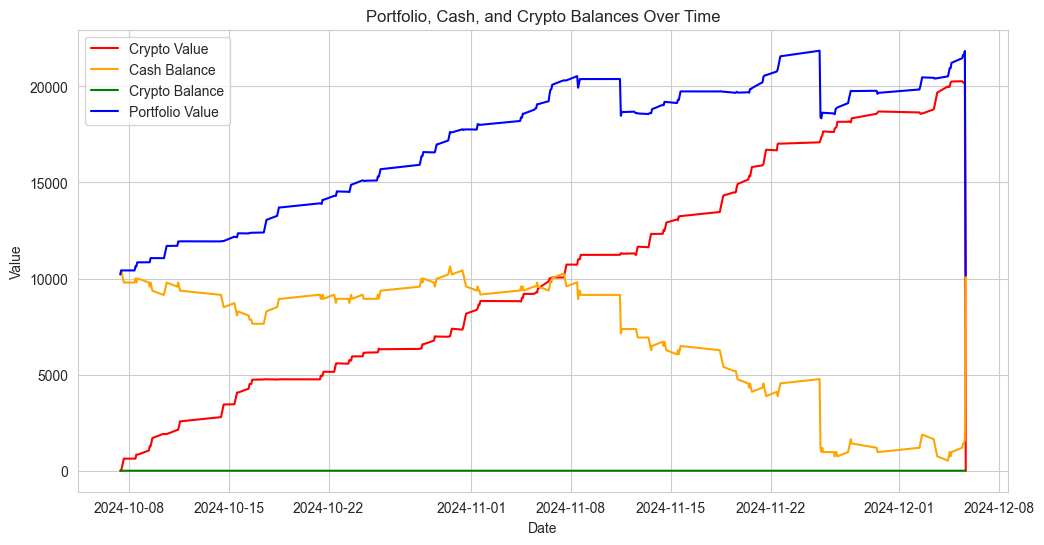

In [90]:
# Plot Portfolio, Cash, and Crypto Balances Over Time
plt.figure(figsize=(12, 6))

plt.plot(time, crypto_value, label="Crypto Value", color="red")
plt.plot(cash_df["Date"], cash_df["Cash Balance"], label="Cash Balance", color="orange")
plt.plot(crypto_df["Date"], crypto_df["Crypto Balance"], label="Crypto Balance", color="green")
plt.plot(portfolio_df["Date"], portfolio_df["Portfolio Value"], label="Portfolio Value", color="blue")

plt.title("Portfolio, Cash, and Crypto Balances Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()


In [68]:
portfolio_df["Portfolio Value"]

0      10211.447559
1      10211.447559
2      10211.034707
3      10210.531816
4      10209.052969
           ...     
208    22894.255430
209    22841.923086
210    22819.972930
211    22824.314434
212    10022.971191
Name: Portfolio Value, Length: 213, dtype: float64

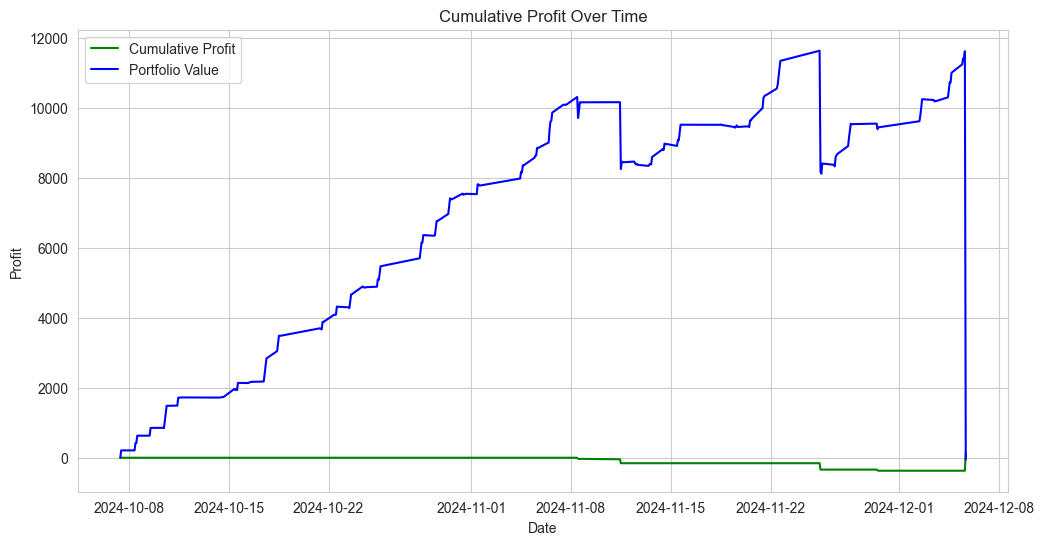

In [91]:
# Plot Profits Over Time
plt.figure(figsize=(12, 6))
plt.plot(profits_df["Date"], profits_df["Cumulative Profit"], label="Cumulative Profit", color="green")
plt.plot(portfolio_df["Date"], portfolio_df["Portfolio Value"] - portfolio_df["Portfolio Value"].iloc[0], label="Portfolio Value", color="blue")

plt.title("Cumulative Profit Over Time")
plt.xlabel("Date")
plt.ylabel("Profit")
plt.legend()
plt.show()

In [92]:
# show the rows with the highest gross profit
positions.sort_values('Gross Profit', ascending=True).head()

,Date Bought,Price Bought,Price Sold,Value Sold,Gross Profit,Time Sold,Time Held,Coins,Type
5,2024-10-08 11:00:00-04:00,41974.328125,44393.878906,221.969395,-12.097754,2024-11-11 11:00:00-05:00,34 days 01:00:00,0.005,short
0,2024-10-07 09:30:00-04:00,42289.511719,44693.808594,223.469043,-12.021484,2024-11-25 11:00:00-05:00,49 days 02:30:00,0.005,short
80,2024-11-04 09:30:00-05:00,42004.660156,44393.878906,221.969395,-11.946094,2024-11-11 11:00:00-05:00,7 days 01:30:00,0.005,short
7,2024-10-08 14:00:00-04:00,42005.281250,44393.878906,221.969395,-11.942988,2024-11-11 11:00:00-05:00,33 days 22:00:00,0.005,short
64,2024-10-29 12:30:00-04:00,42309.488281,44693.808594,223.469043,-11.921602,2024-11-25 11:00:00-05:00,26 days 23:30:00,0.005,short


In [71]:
import plotly.graph_objects as go
import pandas as pd

# Example DataFrames
# btc and positions should already be defined in your code

# Create a figure
fig = go.Figure()

# Add the 'Open' price line
fig.add_trace(go.Scatter(
    x=btc.index,
    y=btc['Open'],
    mode='lines',
    name='Open',
    line=dict(color='blue')
))

# Add buy positions
buy_positions = positions[positions['Type'] == 'buy']
for idx, position in buy_positions.iterrows():
    if pd.notna(position['Price Sold']):
        color = 'green' if position['Gross Profit'] > 0 else 'red'
        fig.add_trace(go.Scatter(
            x=[position['Date Bought'], position['Time Sold']],
            y=[position['Price Bought'], position['Price Sold']],
            mode='lines+markers',
            line=dict(color=color),
            name='Buy/Profit' if color == 'green' else 'Buy/Loss'
        ))

# Add short positions
short_positions = positions[positions['Type'] == 'short']
for idx, position in short_positions.iterrows():
    if pd.notna(position['Price Sold']):
        color = 'green' if position['Gross Profit'] > 0 else 'red'
        fig.add_trace(go.Scatter(
            x=[position['Date Bought'], position['Time Sold']],
            y=[position['Price Bought'], position['Price Sold']],
            mode='lines+markers',
            line=dict(color=color),
            name='Short/Profit' if color == 'green' else 'Short/Loss'
        ))

# Update layout for interactivity and style
fig.update_layout(
    title='XRP-USD',
    xaxis_title='Date',
    yaxis_title='Price',
    template='plotly_white',
    legend_title='Positions',
    xaxis=dict(range=[btc.index[-DAYS], btc.index[-1]])
)

# export to html
fig.write_html('plot.html')


' plt.xlim(btc.index[-1] - pd.DateOffset(days=DAYS), btc.index[-1]) '

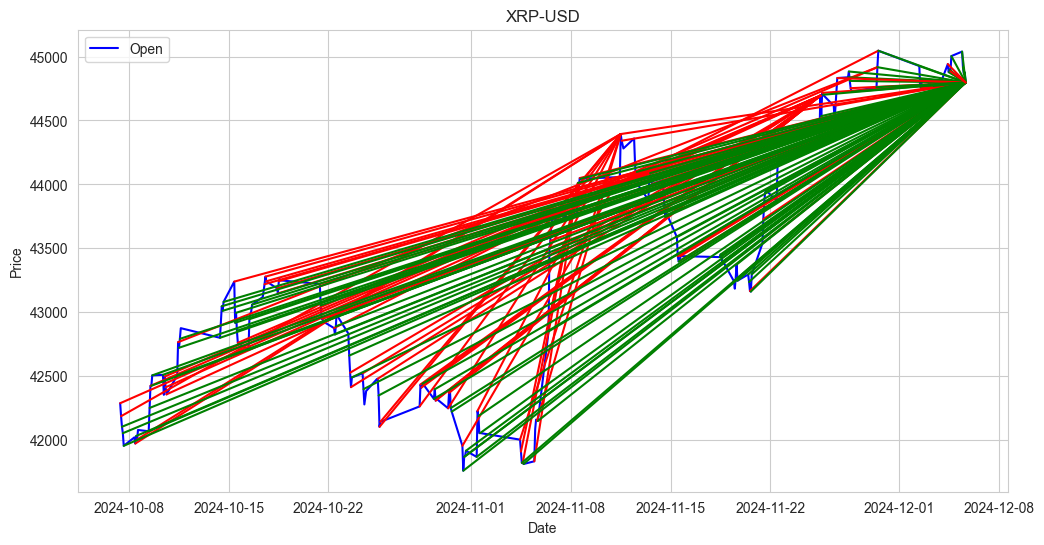

In [93]:
sns.set_style('whitegrid')

plt.figure(figsize=(12, 6))


plt.plot(btc['Open'], label='Open', color='blue')

# graph the buy positions
""" plt.plot(positions[positions['Type'] == 'buy']['Date Bought'], 
         positions[positions['Type'] == 'buy']['Price Bought'], 
         'o', markersize=5, color='green', label='Buy') """

# starting from price bought draw a line to price sold
for idx, position in positions[positions['Type'] == 'short'].iterrows():
    if pd.notna(position['Price Sold']):
        color = 'green' if position['Gross Profit'] > 0 else 'red'
        plt.plot([position['Date Bought'], position['Time Sold']], 
                 [position['Price Bought'], position['Price Sold']], 
                 color=color)

# starting from price bought draw a line to price sold
for idx, position in positions[positions['Type'] == 'buy'].iterrows():
    if pd.notna(position['Price Sold']):
        color = 'green' if position['Gross Profit'] > 0 else 'red'
        plt.plot([position['Date Bought'], position['Time Sold']], 
                 [position['Price Bought'], position['Price Sold']], 
                 color=color)
        
""" 
# graph the short positions
plt.plot(positions[positions['Type'] == 'short']['Date Bought'], 
         positions[positions['Type'] == 'short']['Price Bought'], 
         'o', markersize=5, color='red', label='Short') """



plt.legend()

plt.title('XRP-USD')
plt.xlabel('Date')
plt.ylabel('Price')

DAYS = 30

""" plt.xlim(btc.index[-1] - pd.DateOffset(days=DAYS), btc.index[-1]) """

In [94]:
# run the model 1000 times and calculate the min, max, average, and std of portfolio value and profit
values = ['min', 'max', 'mean', 'std', 'end', '1st', 'median', '3rd']
columns = ['PortfolioValue', 'CumulativeProfit']
result_df = pd.DataFrame(columns=[column + '_' + value for column in columns for value in values])
result_df.head()

,PortfolioValue_min,PortfolioValue_max,PortfolioValue_mean,PortfolioValue_std,PortfolioValue_end,PortfolioValue_1st,PortfolioValue_median,PortfolioValue_3rd,CumulativeProfit_min,CumulativeProfit_max,CumulativeProfit_mean,CumulativeProfit_std,CumulativeProfit_end,CumulativeProfit_1st,CumulativeProfit_median,CumulativeProfit_3rd


In [97]:
RUNS = 30

for i in range(RUNS):
    reset()
    execute_trades(btc, coin_orders=COIN_ORDERS)
    portfolio_df = pd.DataFrame(portfolio_value, columns=["Date", "Portfolio Value"])
    profits_df = pd.DataFrame(profits_over_time, columns=["Date", "Cumulative Profit"])

    for column in result_df.columns:
        dataframe = None
        if 'PortfolioValue' in column:
            dataframe = portfolio_df
        elif 'CumulativeProfit' in column:
            dataframe = profits_df
        
        if 'min' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].min()
        elif 'max' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].max()
        elif 'mean' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].mean()
        elif 'std' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].std()
        elif 'end' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].iloc[-1]
        elif '1st' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].quantile(0.25)
        elif 'median' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].median()
        elif '3rd' in column:
            result_df.loc[i, column] = dataframe[dataframe.columns[1]].quantile(0.75)

        # print with /r
        print(f'\r{i} / {RUNS}', end='')

result_df.head()

C:\Users\akash\AppData\Local\Temp\ipykernel_2024\3279033801.py:59: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



0 / 30

C:\Users\akash\AppData\Local\Temp\ipykernel_2024\3279033801.py:74: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



1 / 30

C:\Users\akash\AppData\Local\Temp\ipykernel_2024\3279033801.py:59: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



...

C:\Users\akash\AppData\Local\Temp\ipykernel_2024\3279033801.py:59: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



28 / 30

C:\Users\akash\AppData\Local\Temp\ipykernel_2024\3279033801.py:59: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



29 / 30

,PortfolioValue_min,PortfolioValue_max,PortfolioValue_mean,PortfolioValue_std,PortfolioValue_end,PortfolioValue_1st,PortfolioValue_median,PortfolioValue_3rd,CumulativeProfit_min,CumulativeProfit_max,CumulativeProfit_mean,CumulativeProfit_std,CumulativeProfit_end,CumulativeProfit_1st,CumulativeProfit_median,CumulativeProfit_3rd
0,10000.0,21780.722402,17387.277651,3314.473491,10066.115371,15390.35584,18410.403379,19902.33752,-367.903398,66.115371,-100.179209,131.497307,66.115371,-179.149805,0.0,0.0
1,10056.23875,22455.252949,17128.639784,3614.528709,10056.23875,14097.454473,18149.594902,20108.486836,-335.051055,56.23875,-87.382232,119.112917,56.23875,-143.180605,0.0,0.0
2,9841.755098,24274.815293,18283.444524,3892.58311,9841.755098,15586.640078,19671.054258,21255.848965,-414.821914,0.0,-112.206105,148.666064,-158.244902,-188.246035,0.0,0.0
3,9997.166191,22845.687266,17681.000051,3440.799062,9997.166191,15167.516641,18401.09498,20717.720645,-368.595508,0.0,-103.850445,134.722194,-2.833809,-189.383145,0.0,0.0
4,9909.164414,22321.336719,17608.455556,3618.286321,9909.164414,14512.949609,19101.471719,20315.524355,-460.221602,0.0,-114.000803,156.46659,-90.835586,-179.85625,0.0,0.0


In [ ]:
# format all columns as numeric
result_df = result_df.apply(pd.to_numeric, errors='coerce')

result_df.describe()

,PortfolioValue_min,PortfolioValue_max,PortfolioValue_mean,PortfolioValue_std,PortfolioValue_end,PortfolioValue_1st,PortfolioValue_median,PortfolioValue_3rd,CumulativeProfit_min,CumulativeProfit_max,CumulativeProfit_mean,CumulativeProfit_std,CumulativeProfit_end,CumulativeProfit_1st,CumulativeProfit_median,CumulativeProfit_3rd
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,100.0,100.0
mean,10079.821069,22381.494776,17340.096263,3401.684690,21136.180488,14740.678609,18352.820697,20076.838786,-373.813131,0.0,-100.445207,133.544705,-373.813131,-165.270571,0.0,0.0
std,103.348146,1244.896800,773.881098,383.747537,1924.351642,785.357469,1002.219343,1039.448308,47.547248,0.0,13.235124,16.706833,47.547248,28.073562,0.0,0.0
min,9995.940703,19219.993613,15572.330918,2391.087061,15795.005273,13026.117832,16084.441621,17560.644453,-481.160645,0.0,-131.739687,88.414649,-481.160645,-246.552773,0.0,0.0
25%,9999.563496,21629.855742,16832.007549,3167.008616,19992.477075,14285.038535,17687.201445,19469.808989,-406.590996,0.0,-110.700357,122.375378,-406.590996,-179.370098,0.0,0.0
50%,10000.000000,22426.289863,17470.494180,3443.361889,21503.335723,14737.051992,18407.036826,20282.359336,-370.226152,0.0,-100.472324,133.186409,-370.226152,-167.424043,0.0,0.0
75%,10211.258975,23267.976743,17927.657826,3669.188284,22514.692944,15345.758066,19003.406943,20710.559453,-338.219604,0.0,-90.843806,144.500301,-338.219604,-145.599414,0.0,0.0
max,10211.447559,25070.251387,19108.872668,4106.532928,25040.809492,16855.973906,20520.421602,22252.152090,-246.178437,0.0,-66.609356,171.448001,-246.178437,-90.096230,0.0,0.0


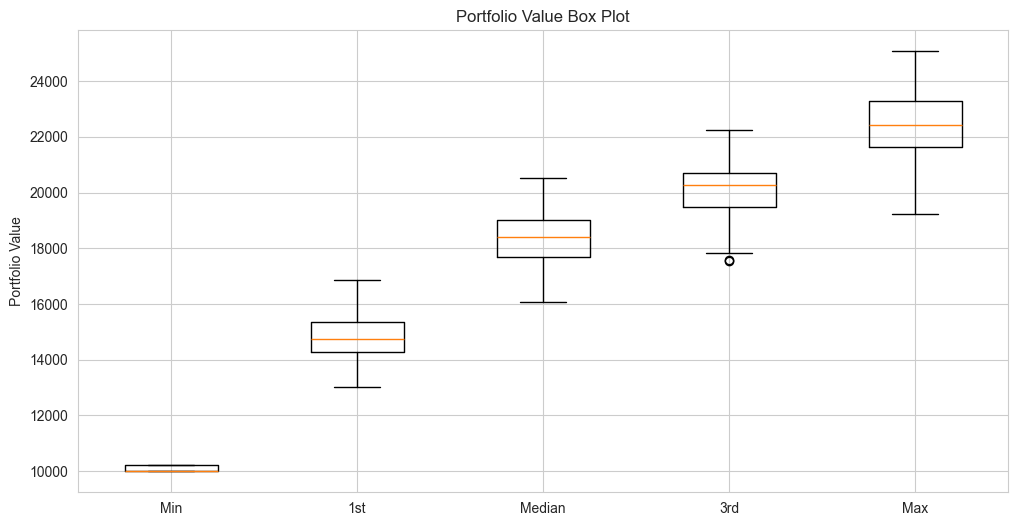

In [ ]:
# create two box plots for portfolio value and cumulative profit
# use the mean of min, 1st, median, 3rd, and max
plt.figure(figsize=(12, 6))

plt.boxplot([result_df['PortfolioValue_min'], result_df['PortfolioValue_1st'],
                result_df['PortfolioValue_median'], result_df['PortfolioValue_3rd'],
                result_df['PortfolioValue_max']],
                labels=['Min', '1st', 'Median', '3rd', 'Max'])

plt.title('Portfolio Value Box Plot')
plt.ylabel('Portfolio Value')
plt.show()

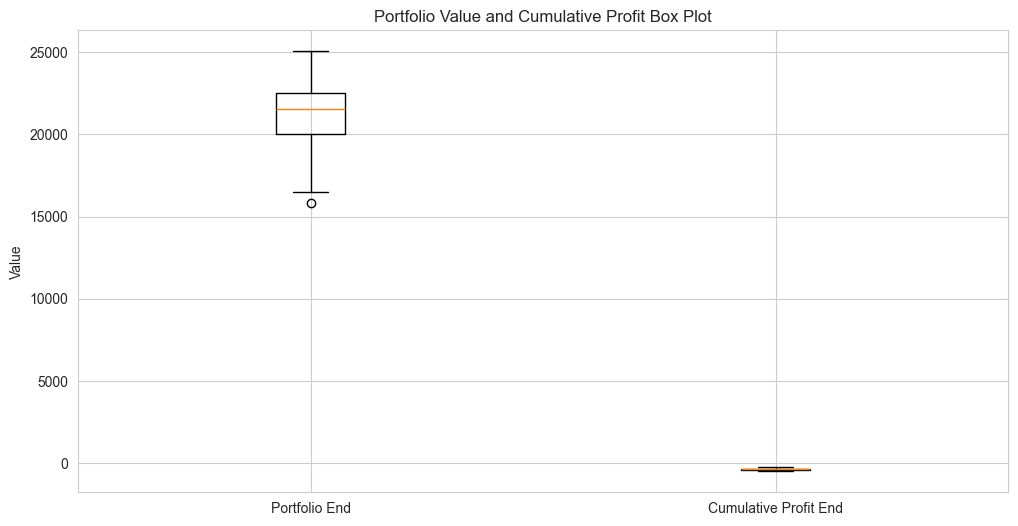

In [ ]:
# create one box plot for portfolio value
plt.figure(figsize=(12, 6))

plt.boxplot([result_df['PortfolioValue_end'], result_df['CumulativeProfit_end']],
                labels=['Portfolio End', 'Cumulative Profit End'])

plt.title('Portfolio Value and Cumulative Profit Box Plot')
plt.ylabel('Value')
plt.show()

In [ ]:
result_df.to_csv('data/results/naive_even_equal.csv')

In [ ]:
# open every csv file in the data/results folder and create a box plot for PortfolioValue_end and CumulativeProfit_end
import glob

files = glob.glob('data/results/*.csv')

dfs = []
for file in files:
    dfs.append(pd.read_csv(file))

portfolio_value = []
cumulative_profit = []

for df in dfs:
    portfolio_value.append(df['PortfolioValue_end'])
    cumulative_profit.append(df['CumulativeProfit_end'])


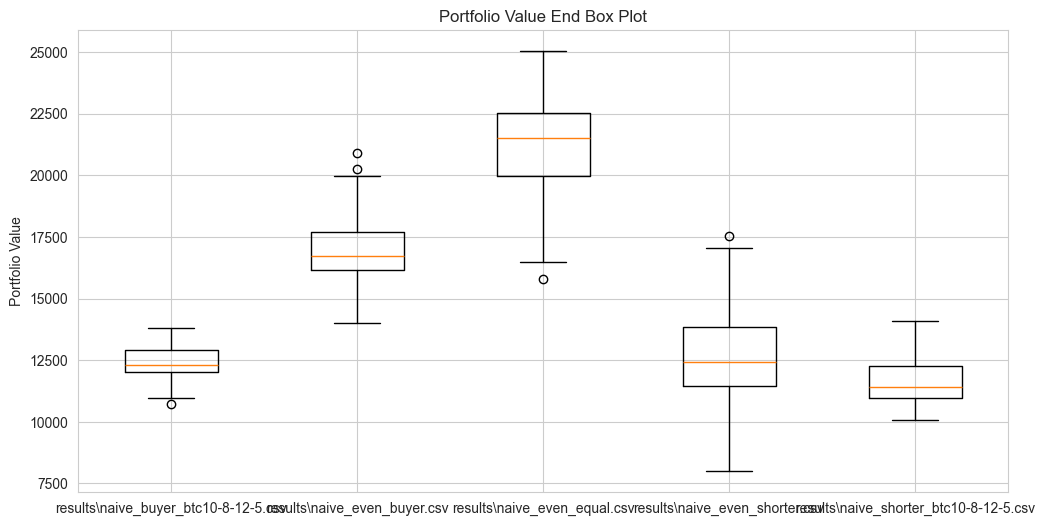

In [ ]:
plt.figure(figsize=(12, 6))

plt.boxplot(portfolio_value, labels=[file.split('/')[-1] for file in files])

plt.title('Portfolio Value End Box Plot')
plt.ylabel('Portfolio Value')
plt.show()